# Part 1: Data Inspection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

diamonds=sns.load_dataset("diamonds")

In [ ]:
print("First 5 rows:")
print(diamonds.head())

First 5 rows:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75


In [ ]:
print("Shape of the dataset:")
diamonds.shape

Shape of the dataset:


(53940, 10)

In [ ]:
print("Data types:")
print(diamonds.dtypes)

Data types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


In [ ]:
print("Summary Statistics:")
print(diamonds.describe(include="all"))

Summary Statistics:
               carat    cut  color clarity         depth         table  \
count   53940.000000  53940  53940   53940  53940.000000  53940.000000   
unique           NaN      5      7       8           NaN           NaN   
top              NaN  Ideal      G     SI1           NaN           NaN   
freq             NaN  21551  11292   13065           NaN           NaN   
mean        0.797940    NaN    NaN     NaN     61.749405     57.457184   
std         0.474011    NaN    NaN     NaN      1.432621      2.234491   
min         0.200000    NaN    NaN     NaN     43.000000     43.000000   
25%         0.400000    NaN    NaN     NaN     61.000000     56.000000   
50%         0.700000    NaN    NaN     NaN     61.800000     57.000000   
75%         1.040000    NaN    NaN     NaN     62.500000     59.000000   
max         5.010000    NaN    NaN     NaN     79.000000     95.000000   

               price             x             y             z  
count   53940.000000  5394

In [ ]:
print("Null values:")
print(diamonds.isnull().sum())

Null values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


# Part 1 Analysis
This is a large dataset with 53,940 rows. There are three categorical variables: cut, color, and clarity, with the remaining variables either integers or floats. Price has the most variability, with an interquartile range of 4,374. There are no missing values in the dataset.

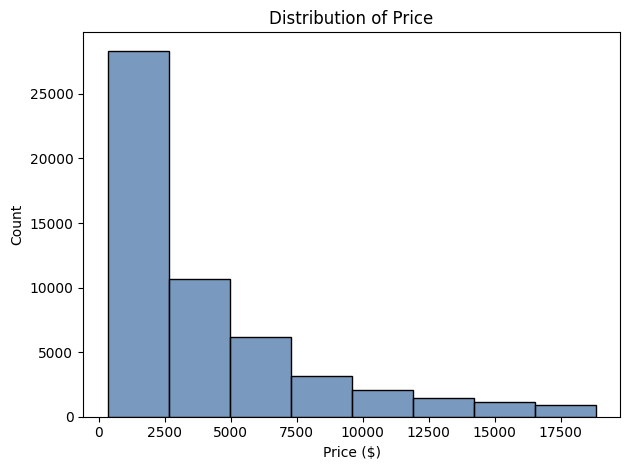

In [ ]:
sns.histplot(
    data=diamonds,
    x="price",
    bins=8,
    color="#4C78A8"
)

plt.title("Distribution of Price")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Half of all diamonds were sold for a price under \$2500, which shows the mean of \$3,932 is inflated by the much smaller amount of diamonds sold for more than \$10,000.

In [ ]:
diamonds["price_per_carat"] = diamonds["price"] / diamonds["carat"]

diamonds[["price", "carat", "price_per_carat"]].head()

,price,carat,price_per_carat
0,326,0.23,1417.391304
1,326,0.21,1552.380952
2,327,0.23,1421.739130
3,334,0.29,1151.724138
4,335,0.31,1080.645161


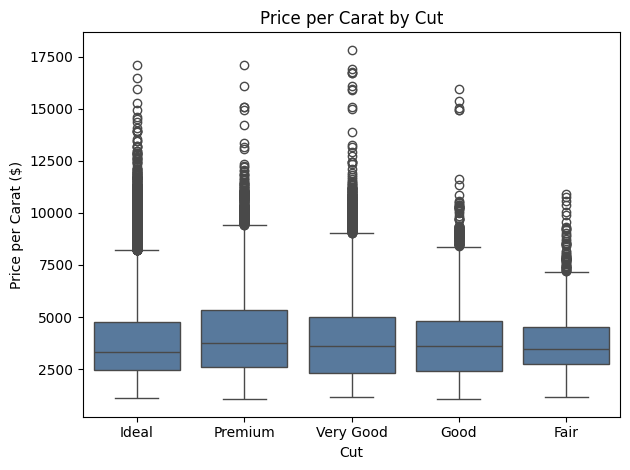

In [ ]:
sns.boxplot(
    data=diamonds,
    x="cut",
    y="price_per_carat",
    color="#4C78A8"
)

plt.title("Price per Carat by Cut")
plt.xlabel("Cut")
plt.ylabel("Price per Carat ($)")
plt.tight_layout()
plt.show()

Price per carat is consistent across cut quality, with Premium showing a slightly higher median and IQR than Ideal. The highest individual outlier comes from the Very Good cut, which could be explained by the higher carat weights of lower quality cuts.

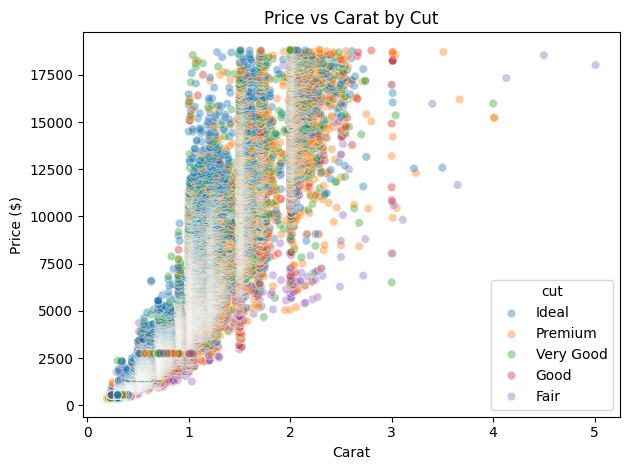

In [ ]:
sns.scatterplot(
    data=diamonds,
    x="carat",
    y="price",
    hue="cut",
    alpha=0.4,
)

plt.title("Price vs Carat by Cut")
plt.xlabel("Carat")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

There is a strong positive relationship between carat weight and price. Higher-carat diamonds skew towards lower cut grades.

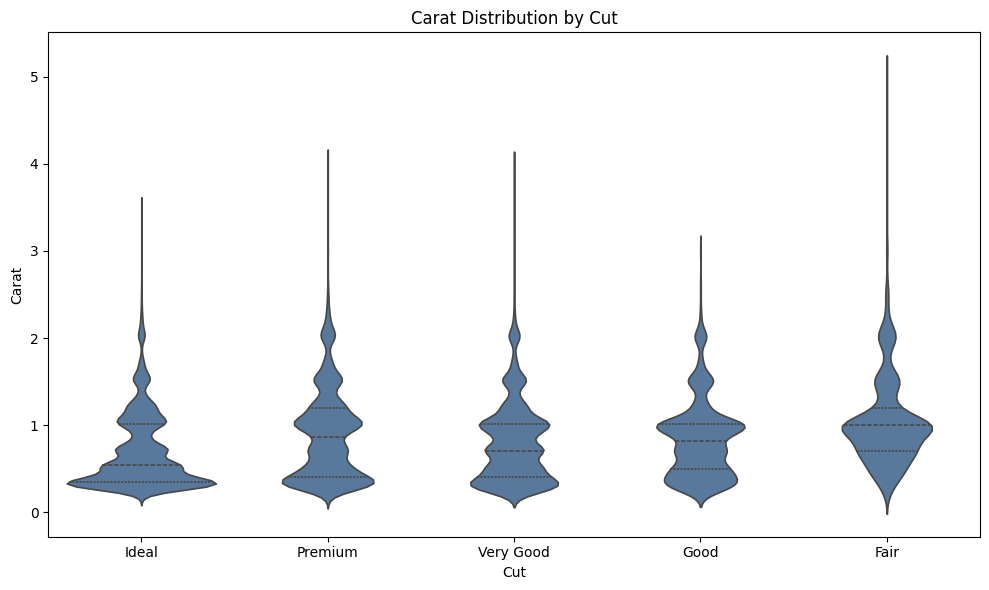

In [ ]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=diamonds,
    x="cut",
    y="carat",
    inner="quartile",
    color="#4C78A8"
)

plt.title("Carat Distribution by Cut")
plt.xlabel("Cut")
plt.ylabel("Carat")
plt.tight_layout()
plt.show()

Ideal cut diamonds are heavily concentrated at lower carat weights, while Fair cut diamonds show a broader distribution centered on the median. This reinforces the observation that lower quality cuts tend to be larger stones.

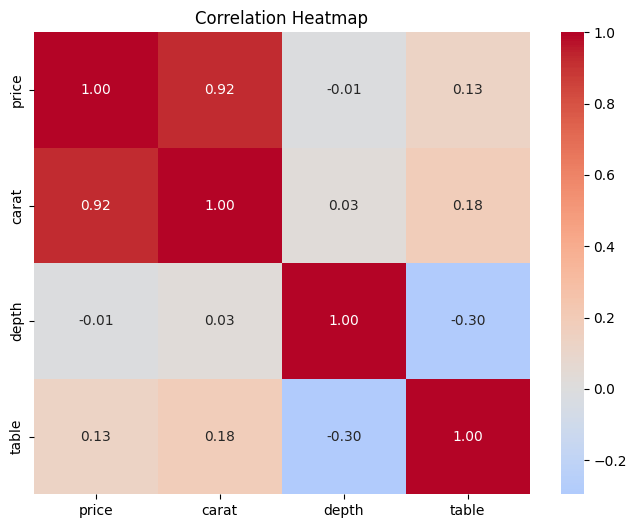

In [ ]:
corr = diamonds[["price", "carat", "depth", "table"]].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

Price and carat weight have a very strong positive correlation, while Depth and Table do not have a strong relationship to any other variables.